# NB08c: Full-Manifest Parquet Audit Sweep v8 (direction-aware temporal aggregation)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.

## v8 changes vs v7

Replaces universal `mean+std` temporal aggregation in `aggregate_long_to_wide()` with
direction-aware temporal reductions per matched-filter principle (Kay 1998,
Glaz-Naus-Wallenstein 2001), aligning NB08c with the methodology already
implemented in NB05b v29 (statistic-aware spatial aggregation) and NB03e v47/v48
(per-pixel temporal extremum at multiple scopes via R3/R4/R5/R7 + R2b + P1d).

Reference: `DECISION_Rolling_Block_Accumulators.md` Sec 5 (operator formulas) and
`DECISION_NB05b_v29_Zonal_Aggregation.md` Sec 1 (the empirical case for matched
filter at the temporal axis).

Per-column temporal reductions dispatched via modality token in column name:

- **drop modalities** (coh_vv, coh_vh, vv, b08, b8a, ndvi, savi, ndbi, ibi, baei, ui)
  -> temporal `min, mean, std`. Min is the Neyman-Pearson optimal detector for a
  1-of-N drop spike on stationary noise.
- **rise modalities** (b11, b12, bsi) -> temporal `max, mean, std`. Max is the
  N-P optimal detector for a 1-of-N rise spike (rubble exposure).
- **mixed-sign modalities** (vh, nbr, mndwi, ndsi) -> temporal `min, max, mean, std`.
- **unknown / non-mappable** (raw VIS bands b02/b03/b04/b05/b07, aux columns,
  fire products, landuse fractions) -> temporal `mean, std` (legacy v7 fallback).

Accumulator-derived long parquets (manifest keys A23 `rolling_accum_coh`,
A24 `rolling_accum_card`, A25 `rolling_accum_ms`) keep universal `mean + std`
because their pixel-temporal axis was already extremized inside NB03e R2b. Applying
another temporal extremum here would just collapse to A14/A19/A20/A21 full-post-battle
accumulators, making A23-A25 redundant.

Categorical long parquets (A4 `scene_landuse`, A12 `composite_vs_scenes_landuse`)
still flow through the `unknown -> mean+std` path. Per-class trajectory aggregators
(modal trajectory, persistence, urban_or_bare_frac temporal extremum) are flagged
as a TODO for a follow-up release; the numeric class-fraction columns currently
get mean+std, which is defensible for fractions but not optimal.

No change to: leakage filter, classifier, CV protocol, audit-runner output schema,
ranking, or save_oof contract. The single change is the per-column dispatch inside
`aggregate_long_to_wide()`, plus passing `manifest_key` through from `audit_parquet()`.


## v7 changes vs v6

Adds 6 new atomic parquets from NB05b v29 (NB03e v47 R2b/P1d outputs):

- **C5b (new):** A23 rolling_accum_coh, A24 rolling_accum_card, A25 rolling_accum_ms (long format, per-date)
- **C6b (new):** A26 block_accum_coh, A27 block_accum_card, A28 block_accum_ms (wide format, per block × op)
- **C10 ALL_KEYS extended:** clean-vs-leaky AUC delta now also computed for A23–A28

## Metadata-leakage protection (centralized in metadata_filter.py)

v29 introduced two new metadata categories that the audit pipeline now rejects via the central `metadata_filter` module:

- **Battle-calendar columns (date_first_drop, date_worst_drop, date_first_swir_rise, date_persistent_loss, etc.)** — encoded as substrings in the column prefix; their reductions (`__min_nonzero`, `__max`, `__count_unique`) are tagged METADATA regardless of suffix shape. The `__max` suffix here is a date max, not a value max, so substring-on-prefix is the correct discrimination.
- **Geometry-dependent counts (`__n_pixels_valid`)** — emitted by every v29 aggregation helper; suffix-match `__n_pixels_valid$` rejects them.

These join the existing leakage rules (`was_observed_*`, `scenes_observed_*`, `qa__cloud_freq__*`, `visibility__*__freq__*`, `blk*__count_*`) under one centralized module — no per-notebook hand-curation.

## Audit protocol (unchanged from v6)

Single protocol over all v2 parquets. One AUC per parquet for direct comparison.

- Classifier: LightGBM native NaN, class_weight balanced, n_estimators=300
- CV: GroupKFold by city, 5 folds
- Long-format parquets aggregated to per-building mean + std
- Leakage filter: `metadata_filter.is_non_feature()` (covers v28 + v29 patterns)
- Feature set: `MANIFEST['parquets'][key]['feature_columns']` minus leakage minus count-stats

Output:
- `RESULTS_ROOT/nb08c/parquet_ranking.csv` — one row per parquet
- Diagnostic flags: BROKEN, EMPTY, STALE, LEAKAGE_DOMINATED
- Registry tags: `['nb08c_audit']`


Single protocol over all 26 v2 parquets. Produces one AUC per parquet for direct comparison.

- Classifier: LightGBM native NaN, class_weight balanced, n_estimators=300
- CV: GroupKFold by city, 5 folds
- Long-format parquets aggregated to per-building mean + std
- Leakage filter: scenes_observed, obs_count, cloud_freq, visibility__cloud__freq
- Feature set: `MANIFEST['parquets'][key]['feature_columns']` minus leakage minus count-stats

Output:
- `RESULTS_ROOT/nb08c/parquet_ranking.csv` — one row per parquet
- Diagnostic flags: BROKEN, EMPTY, STALE, LEAKAGE_DOMINATED
- Registry tags: `['nb08c_audit']`

# CELL 1: NB08c CONFIG

In [1]:
# @title CELL 1: NB08c CONFIG
TIER_SELECTION = [0,1,2]
CITY_FILTER = None
CITY_SELECTION = None
REQUIRE_UNOSAT = True
RANDOM_STATE = 42
N_FOLDS = 5

USE_V2 = True


# CELL 2: LOAD GLOBAL SETUP

In [2]:
# @title CELL 2: LOAD GLOBAL SETUP
import platform, os, json
if platform.system() == "Windows":
    _setup = r"F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py"
elif os.path.exists("/content/drive_f"):
    _setup = "/content/drive_f/masterthesis/notebooks/global_setup.py"
else:
    _setup = "/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py"
with open(_setup) as f:
    exec(f.read())


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


BDA GLOBAL SETUP
Started: 2026-04-26 19:09:12
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     910.6/7452.0 GB (6541.4 GB free)
  GDrive (F:)     1387.7/3726.0 GB (2338.3 GB free)
  Local data      11560.9/14901.9 GB (3341.0 GB free)
  Data stack      1387.7/3726.0 GB (2338.3 GB free)
  WSL ext4        68.6/1006.9 GB (887.1 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL S0: MANIFEST + BUILDINGS + SHARED HELPERS

Same pattern as NB09a v2 S0. Defines `load_v2()`, `drop_leakage()`,
`aggregate_long_to_wide()`, `prepare_features()`, `evaluate_groupkfold()`.


In [3]:
# @title CELL S0: LOAD MANIFEST + BUILDINGS + SHARED HELPERS
import sys, importlib, re, gc, time
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score)
from sklearn.base import clone
import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("CELL S0: NB08c v2 - LOAD MANIFEST + BUILDINGS + SHARED HELPERS")
print("=" * 70)

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import metadata_filter
importlib.reload(metadata_filter)
from metadata_filter import (
    ID_COLS, LABEL_COLS, META_COLS_SET,
    is_metadata, is_non_feature,
    select_feature_columns, build_role_overrides,
)

# --- load v2 manifest -------------------------------------------------
MANIFEST_V2_PATH = DATASET_ROOT_V2 / 'parquet_manifest.json'
if not MANIFEST_V2_PATH.exists():
    raise FileNotFoundError(f"V2 manifest not found: {MANIFEST_V2_PATH}")
with open(MANIFEST_V2_PATH) as _f:
    MANIFEST = json.load(_f)
print(f"  Manifest: {MANIFEST_V2_PATH}")
print(f"  Version: {MANIFEST['version']}  Created: {MANIFEST['created']}")
print(f"  Parquets in manifest: {len(MANIFEST['parquets'])}")

# --- load building metadata (v2 path) --------------------------------
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
_bldg_pattern = str(DATASET_ROOT_V2 / 'bda_buildings_t{tier}.parquet')
df_bldg = load_tier_parquets(_bldg_pattern, _tiers)
CITIES_TO_PROCESS, _battle_dates = resolve_cities(
    tier_selection=TIER_SELECTION,
    city_selection=[CITY_FILTER] if isinstance(CITY_FILTER, str) else CITY_FILTER,
    require_unosat=REQUIRE_UNOSAT,
)
df_bldg = df_bldg[df_bldg['city'].isin(CITIES_TO_PROCESS)].copy()
df_bldg = df_bldg[df_bldg['damage_binary'] >= 0].copy()
print(f"  Cities: {len(CITIES_TO_PROCESS)}")
print(f"  Buildings: {len(df_bldg)} (damaged={int((df_bldg['damage_binary']==1).sum())}, "
      f"undamaged={int((df_bldg['damage_binary']==0).sum())})")

TARGET_COL = 'damage_binary'
AUDIT_LOG = {}

# ---- NB12 overlap-analysis: canonical OOF predictions schema ----
import hashlib as _hashlib, datetime as _dt
EXPERIMENT_ID = _dt.datetime.now().strftime('%Y%m%d_%H%M%S') + '_' + _hashlib.md5(
    f'nb08c_{TIER_SELECTION}_{REQUIRE_UNOSAT}'.encode()).hexdigest()[:6]
print(f"  EXPERIMENT_ID: {EXPERIMENT_ID}")

def save_oof_from_result(res, model_id, oof_dir, variant_id='',
                         is_final=False, threshold=0.5):
    '''Canonical OOF schema: building_id, city, fold_id, y_true, y_proba, y_pred,
       cm_class, model_id, experiment_id, variant_id, is_final.'''
    if res is None:
        return None
    needed = ('y_true', 'y_proba', 'groups', 'building_id', 'fold_id')
    if not all(k in res for k in needed):
        print(f"    [save_oof] skipped {model_id}: missing keys (need {needed})")
        return None
    y_proba = np.asarray(res['y_proba'])
    yt = np.asarray(res['y_true']).astype(int)
    fold = np.asarray(res['fold_id']).astype(int)
    bid = np.asarray(res['building_id'])
    cty = np.asarray(res['groups'])
    yp = (y_proba >= threshold).astype(int)
    cm_class = np.where(yt == 1,
                        np.where(yp == 1, 'TP', 'FN'),
                        np.where(yp == 1, 'FP', 'TN'))
    oof_df = pd.DataFrame({
        'building_id':   bid,
        'city':          cty,
        'fold_id':       fold,
        'y_true':        yt,
        'y_proba':       y_proba.astype(float),
        'y_pred':        yp,
        'cm_class':      cm_class,
        'model_id':      model_id,
        'experiment_id': EXPERIMENT_ID,
        'variant_id':    variant_id,
        'is_final':      bool(is_final),
    })
    oof_dir = Path(oof_dir)
    oof_dir.mkdir(parents=True, exist_ok=True)
    out = oof_dir / f'oof_{model_id}__{EXPERIMENT_ID}.parquet'
    oof_df.to_parquet(out, index=False)
    n_tp = int((cm_class == 'TP').sum()); n_fn = int((cm_class == 'FN').sum())
    n_fp = int((cm_class == 'FP').sum()); n_tn = int((cm_class == 'TN').sum())
    print(f"    saved oof -> {out.name}  TP={n_tp} FN={n_fn} FP={n_fp} TN={n_tn}")
    return out

# --- leakage filter ---------------------------------------------------
LEAKAGE_EXCLUDE_PATTERNS = [
    r's1__coh__scenes_observed',
    r's1__vv__scenes_observed',
    r's2__scenes_observed',
    r's2__lu__scenes_observed',
    r's2__obs_count__',
    r's2__qa__cloud_freq__',
    r's2__visibility__cloud__freq',
    r'was_observed_',
]
# -- leaky filter (legacy NB08c behavior, keeps was_observed_ flags; used by C10 for delta comparison) --
LEAKAGE_LEAKY_PATTERNS = [
    r's1__coh__scenes_observed',
    r's1__vv__scenes_observed',
    r's2__scenes_observed',
    r's2__lu__scenes_observed',
    r's2__obs_count__',
    r's2__qa__cloud_freq__',
    r's2__visibility__cloud__freq',
]
_LEAKAGE_LEAKY_RE = [re.compile(p) for p in LEAKAGE_LEAKY_PATTERNS]

def drop_leakage_leaky(cols):
    '''LEGACY filter that keeps was_observed_* flags. For C10 delta only. Do not use elsewhere.'''
    return [c for c in cols if not any(rx.search(c) for rx in _LEAKAGE_LEAKY_RE)]
_LEAKAGE_RE = [re.compile(p) for p in LEAKAGE_EXCLUDE_PATTERNS]

def drop_leakage(cols):
    return [c for c in cols if not any(rx.search(c) for rx in _LEAKAGE_RE)]

def _has_count_stat(c):
    parts = c.split('__')
    if len(parts) < 4:
        return False
    return parts[3].split('_')[0] == 'count'

# --- v2 manifest-driven loader (copy of NB09a v2 signature) ----------
def load_v2(manifest_key, tiers=None, columns=None, sample_frac=None):
    '''Load a v2 parquet by manifest key, merge with buildings, return df.'''
    if manifest_key not in MANIFEST['parquets']:
        raise KeyError(f"Manifest key not found: {manifest_key}")
    info = MANIFEST['parquets'][manifest_key]
    fname_tmpl = Path(info['pattern']).name
    tiers = tiers if tiers is not None else _tiers

    frames = []
    for t in tiers:
        pf = DATASET_ROOT_V2 / fname_tmpl.format(tier=t)
        if not pf.exists():
            continue
        if columns is not None:
            join_cols = info.get('join_keys', ['city', 'building_id'])
            read_cols = list(dict.fromkeys(join_cols + list(columns)))
            try:
                df_t = pd.read_parquet(pf, columns=read_cols)
            except Exception:
                df_t = pd.read_parquet(pf)
                keep = [c for c in read_cols if c in df_t.columns]
                df_t = df_t[keep]
        else:
            df_t = pd.read_parquet(pf)
        if sample_frac is not None and 0 < sample_frac < 1:
            df_t = df_t.sample(frac=sample_frac, random_state=RANDOM_STATE)
        frames.append(df_t)
    if not frames:
        raise FileNotFoundError(f"No v2 parquets found for key={manifest_key} tiers={tiers}")
    df = pd.concat(frames, ignore_index=True)
    del frames

    df = df.loc[:, ~df.columns.duplicated()]
    df = df[df['city'].isin(CITIES_TO_PROCESS)].copy()
    if TARGET_COL not in df.columns:
        df = df.merge(df_bldg[['building_id', 'city', TARGET_COL]].drop_duplicates(),
                      on=['building_id', 'city'], how='inner')
    df = df[df[TARGET_COL] >= 0].copy()
    df = df.loc[:, ~df.columns.duplicated()]
    return df

# --- v8: direction-aware temporal aggregation (matched-filter principle) ---
# Damage at the temporal axis is a sparse-event spike. Per Kay 1998 (Detection
# Theory) and Glaz-Naus-Wallenstein 2001 (Scan Statistics), the rolling extremum
# is the Neyman-Pearson optimal detector for a 1-of-N spike on stationary noise.
# v7 universal mean+std attenuated the spike; v8 dispatches per modality direction.
# Reference: DECISION_Rolling_Block_Accumulators.md Sec 5; DECISION_NB05b_v29 Sec 1.

DIRECTION_BY_MODALITY = {
    # SAR drop signals (damage -> coherence loss, VV backscatter loss on rough->smooth or rubble)
    'coh_vv': 'drop', 'coh_vh': 'drop',
    'vv': 'drop',
    # SAR mixed-sign (volume scattering can go either direction with rubble)
    'vh': 'mixed',
    # MS visible bands -- no clean damage direction (illumination + atmosphere dominate)
    'b02': 'unknown', 'b03': 'unknown', 'b04': 'unknown',
    'b05': 'unknown', 'b07': 'unknown',
    # MS NIR -- vegetation loss after damage drives NIR drop
    'b08': 'drop', 'b8a': 'drop',
    # MS SWIR -- rubble / bare soil exposure drives SWIR rise (Aimaiti 2022)
    'b11': 'rise', 'b12': 'rise',
    # MS derived indices
    'nbr':   'mixed',  # burn / vegetation loss / rubble (sign depends on land cover)
    'ndvi':  'drop',   # vegetation loss
    'savi':  'drop',   # soil-adjusted vegetation
    'bsi':   'rise',   # bare-soil exposure rises with rubble
    'mndwi': 'mixed',  # water -- flood-rise vs drying-drop
    'ndbi':  'drop',   # built-up index drops with built-up loss
    'ndsi':  'mixed',  # snow seasonal noise, no damage direction
    'ibi':   'drop',   # built-up index variant
    'baei':  'drop',   # built-up area extraction index
    'ui':    'drop',   # urban index
}

# Manifest keys whose long parquets are already pixel-temporal-extremized in NB03e R2b.
# For these, mean+std-over-time preserves the per-rolling-window pattern; a second
# temporal extremum would collapse to the full-post-battle accumulators (A14/A19/A20/A21),
# making A23/A24/A25 redundant.
ACCUM_LONG_KEYS = {'rolling_accum_coh', 'rolling_accum_card', 'rolling_accum_ms'}

def _parse_modality_token(col):
    '''Return the modality token (second `__`-separated piece) of a feature column.
       Examples:
         s2__b02__mean              -> b02
         s1__coh_vv__zscore__mean   -> coh_vv
         s1__vv__roll7__min         -> vv
         s2__landuse__urban_frac    -> landuse  (returns 'landuse', falls into 'unknown')
       Returns None if the column has fewer than 2 `__`-separated pieces.'''
    parts = col.split('__')
    if len(parts) < 2:
        return None
    return parts[1].lower()

def _temporal_reductions_for_column(col):
    '''Return the list of pandas agg names to apply over the date axis for `col`,
       chosen by modality direction:
         drop    -> [min, mean, std]
         rise    -> [max, mean, std]
         mixed   -> [min, max, mean, std]
         unknown -> [mean, std]   (legacy v7 fallback for non-mappable columns)
       The `mean` and `std` slots are kept in every direction so v7 features are
       a strict subset of v8 features (additive change, no information lost).'''
    modality = _parse_modality_token(col)
    direction = DIRECTION_BY_MODALITY.get(modality, 'unknown')
    if direction == 'drop':
        return ['min', 'mean', 'std']
    if direction == 'rise':
        return ['max', 'mean', 'std']
    if direction == 'mixed':
        return ['min', 'max', 'mean', 'std']
    return ['mean', 'std']

# --- long-format aggregation (v8: direction-aware temporal collapse) ---------
def aggregate_long_to_wide(df, feat_cols, manifest_key=None):
    '''Collapse a long-format per-scene parquet to per-building summary.

    v8: direction-aware temporal aggregation per matched-filter principle.
    - manifest_key in ACCUM_LONG_KEYS  -> universal mean+std (already extremized in R2b)
    - otherwise                        -> per-column dispatch via _temporal_reductions_for_column

    Backward compatible call: `aggregate_long_to_wide(df, feat_cols)` (manifest_key=None)
    falls through to per-column dispatch with v7-equivalent fallback for unknown columns.
    '''
    feat_cols = [c for c in feat_cols if c in df.columns]
    if not feat_cols:
        return (df.groupby(['city', 'building_id'], sort=False, observed=True)
                  .size().reset_index()[['city', 'building_id']])

    if manifest_key in ACCUM_LONG_KEYS:
        agg_dict = {c: ['mean', 'std'] for c in feat_cols}
    else:
        agg_dict = {c: _temporal_reductions_for_column(c) for c in feat_cols}

    agg = df.groupby(['city', 'building_id'], sort=False, observed=True).agg(agg_dict)
    agg.columns = [f"{a}_{b}" for a, b in agg.columns]
    agg = agg.reset_index()
    return agg

# --- manifest-derived feature set for a given parquet ----------------
def get_parquet_features(manifest_key, df):
    '''Return the cleaned feature column list for a parquet: manifest features,
       intersected with df columns, minus leakage, minus count stats, minus all-NaN.

       Uses metadata_filter.select_feature_columns() so that id/label/metadata
       columns (including any was_observed_* flag, regardless of suffix) are
       excluded centrally rather than by a locally-maintained list.'''
    info = MANIFEST['parquets'][manifest_key]
    raw = [c for c in info.get('feature_columns', []) if c in df.columns]
    if not raw:
        # fallback: metadata_filter picks numeric features, excluding id/label/meta
        # and any was_observed_* via the centralized pattern rule.
        raw = select_feature_columns(df)
    else:
        # manifest-declared features: still scrub in case the manifest lists a
        # column that is actually metadata (defensive, typically a no-op).
        raw = [c for c in raw if not is_non_feature(c)]
    clean = drop_leakage(raw)
    clean = [c for c in clean if not _has_count_stat(c)]
    nan_rate = df[clean].isna().mean() if clean else pd.Series(dtype=float)
    clean = [c for c in clean if nan_rate.get(c, 1.0) < 1.0]
    return clean

# --- LightGBM feature prep (no imputation, native NaN) --------------
def prepare_features_mia(df, feat_cols):
    '''Return X (with NaN preserved), y, groups, building_ids, clean_cols.'''
    if not feat_cols:
        return None
    X = df[feat_cols].to_numpy(dtype=np.float32, copy=False)
    y = df[TARGET_COL].values
    groups = df['city'].values
    building_ids = df['building_id'].values
    return X, y, groups, building_ids, feat_cols

# --- single-protocol GroupKFold evaluator ---------------------------
def evaluate_audit(clf, X, y, groups, experiment_name, n_folds=N_FOLDS,
                   building_ids=None):
    n_cities = len(np.unique(groups))
    n_folds_actual = min(n_folds, n_cities)
    if n_folds_actual < 2:
        print(f"    SKIP {experiment_name}: only {n_cities} cities")
        return None
    gkf = GroupKFold(n_splits=n_folds_actual)
    y_proba_oof = np.full(len(y), np.nan)
    fold_id = np.full(len(y), -1, dtype=int)
    fold_aucs = []
    for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups)):
        clf_c = clone(clf)
        clf_c.fit(X[tr], y[tr])
        proba = clf_c.predict_proba(X[te])[:, 1]
        y_proba_oof[te] = proba
        fold_id[te] = fold_idx
        if len(np.unique(y[te])) > 1:
            fold_aucs.append(roc_auc_score(y[te], proba))
    valid = ~np.isnan(y_proba_oof)
    y_v, p_v = y[valid], y_proba_oof[valid]
    pred_v = (p_v >= 0.5).astype(int)
    bid_v = np.asarray(building_ids)[valid] if building_ids is not None else np.arange(len(y))[valid].astype(str)
    result = {
        'experiment': experiment_name,
        'auc_groupkfold': roc_auc_score(y_v, p_v),
        'f1_groupkfold': f1_score(y_v, pred_v),
        'precision': precision_score(y_v, pred_v, zero_division=0),
        'recall': recall_score(y_v, pred_v, zero_division=0),
        'fold_aucs': fold_aucs,
        'auc_mean': float(np.mean(fold_aucs)) if fold_aucs else float('nan'),
        'auc_std': float(np.std(fold_aucs)) if fold_aucs else float('nan'),
        'n_features': X.shape[1], 'n_buildings': int(valid.sum()),
        'n_cities': int(len(np.unique(groups))),
        'y_true': y_v, 'y_proba': p_v, 'groups': groups[valid],
        'building_id': bid_v, 'fold_id': fold_id[valid],
    }
    AUDIT_LOG[experiment_name] = result
    print(f"    {experiment_name:40s} AUC={result['auc_groupkfold']:.3f}  "
          f"F1={result['f1_groupkfold']:.3f}  n={result['n_buildings']:,}  "
          f"cities={result['n_cities']}  nfeat={result['n_features']}")
    return result

# --- output paths + registry ----------------------------------------
import matplotlib.pyplot as plt
from datetime import datetime as _dt

OUT_DIR = OUTPUTS_DIR / "NB08c_v2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        with open(path, 'w') as fh:
            json.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.relative_to(OUT_DIR)} ({path.stat().st_size / 1024:.1f} KB)")
    return path

def save_fig(fig, name, cell_id, dpi=150):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Plot: {path.relative_to(OUT_DIR)}")
    return path

from bda_results import ResultRegistry
registry = ResultRegistry(RESULTS_ROOT, notebook='NB08c_v2')

def log_audit(res, cell_id, manifest_key, note=''):
    if res is None:
        return
    registry.log_experiment(
        cell_id=cell_id, experiment_name=res['experiment'],
        parquet_name=f'bda_{manifest_key}_v2', feature_set_name='manifest_default_minus_leakage',
        classifier_name='LightGBM-300-MIA', classifier_params=LGBM_PARAMS,
        feature_cols=[], cv_method='GroupKFold', n_folds=N_FOLDS,
        imputation='native_nan', y_true=res['y_true'], y_proba=res['y_proba'],
        groups=res['groups'], note=note, tags=['nb08c_audit'],
    )

print(f"  Helpers: load_v2(), get_parquet_features(), aggregate_long_to_wide(), evaluate_audit()")
print(f"  Output:  {OUT_DIR}")
print(f"  Registry: NB08c_v2")


CELL S0: NB08c v2 - LOAD MANIFEST + BUILDINGS + SHARED HELPERS
  Manifest: /mnt/f/PROJECTS/masterthesis/data_stack/dataset/V2/parquet_manifest.json
  Version: v2  Created: 2026-04-26T16:31:26.125203
  Parquets in manifest: 37
  load_tier_parquets: 3 tiers, 907371 rows
  Cities: 21
  Buildings: 598595 (damaged=7332, undamaged=591263)
  EXPERIMENT_ID: 20260426_191509_115af1
  ResultRegistry: /content/drive_f/masterthesis/results/registry (run_id=20260426_191509)
  Helpers: load_v2(), get_parquet_features(), aggregate_long_to_wide(), evaluate_audit()
  Output:  /content/drive_f/masterthesis/data/outputs/NB08c_v2
  Registry: NB08c_v2


In [4]:
# @title CELL S0b: OOF PLOT + SUMMARY HELPERS
# TP=red, TN=green, FP=pink, FN=gold
import matplotlib.pyplot as plt

CM_COLORS = {'TP': '#d62728', 'TN': '#2ca02c', 'FP': '#ff9ecb', 'FN': '#ffd700'}
CM_LABELS = {'TP': 'Destroyed (TP)', 'TN': 'Not destroyed (TN)',
             'FP': 'False positive (FP)', 'FN': 'False negative (FN)'}

# alias df_bldg to df_buildings for plotting helper compatibility
df_buildings = df_bldg

def print_cm_summary(oof_path_or_df):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else '(unknown)'
    print(f"  model_id: {model_id}   n={len(oof)}")
    overall = oof['cm_class'].value_counts()
    for cls in ['TP', 'TN', 'FP', 'FN']:
        n = int(overall.get(cls, 0))
        pct = 100.0 * n / len(oof) if len(oof) else 0
        print(f"    {cls:3s} {CM_LABELS[cls]:28s}  n={n:6d}  ({pct:5.1f}%)")
    by_city = (oof.groupby('city')['cm_class']
                 .value_counts().unstack(fill_value=0))
    for cls in ['TP', 'TN', 'FP', 'FN']:
        if cls not in by_city.columns:
            by_city[cls] = 0
    by_city = by_city[['TP', 'TN', 'FP', 'FN']]
    by_city['recall']    = by_city['TP'] / (by_city['TP'] + by_city['FN']).replace(0, np.nan)
    by_city['precision'] = by_city['TP'] / (by_city['TP'] + by_city['FP']).replace(0, np.nan)
    print(f"\n  Per-city:")
    print(by_city.to_string(float_format=lambda x: f'{x:.3f}' if pd.notna(x) else '-'))
    return by_city

def plot_cm_spatial(oof_path_or_df, save_name=None, figsize=(14, 10),
                    buildings_df=None, point_size=4):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    bdf = buildings_df if buildings_df is not None else df_buildings
    if 'centroid_x' not in bdf.columns or 'centroid_y' not in bdf.columns:
        print("  plot_cm_spatial: no centroid_x/centroid_y in buildings_df")
        return None
    plot_df = oof.merge(bdf[['building_id', 'city', 'centroid_x', 'centroid_y']],
                        on=['building_id', 'city'], how='inner')
    if len(plot_df) == 0:
        print("  plot_cm_spatial: no building matches")
        return None
    cities = sorted(plot_df['city'].unique())
    ncols = min(3, len(cities))
    nrows = (len(cities) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else ''
    fig.suptitle(f'Confusion-matrix map: {model_id}', fontsize=11)
    draw_order = ['TN', 'FP', 'FN', 'TP']
    for i, city in enumerate(cities):
        ax = axes[i // ncols][i % ncols]
        cdf = plot_df[plot_df['city'] == city]
        for cls in draw_order:
            pts = cdf[cdf['cm_class'] == cls]
            if len(pts) == 0:
                continue
            ax.scatter(pts['centroid_x'], pts['centroid_y'],
                       c=CM_COLORS[cls], s=point_size, alpha=0.75,
                       edgecolors='none',
                       label=f"{CM_LABELS[cls]} (n={len(pts)})")
        ax.set_title(f"{city}  (n={len(cdf)})", fontsize=9)
        ax.set_aspect('equal')
        ax.legend(loc='best', fontsize=6, markerscale=2, framealpha=0.85)
        ax.tick_params(labelsize=7)
    for j in range(len(cities), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_name:
        fig.savefig(OUT_DIR / f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)
    return fig

def plot_cm_oof_all(oof_dir, skip_variants=()):
    d = Path(oof_dir)
    files = sorted(d.glob('oof_*.parquet'))
    print(f"  Found {len(files)} OOF parquets in {d}")
    for p in files:
        oof = pd.read_parquet(p)
        v = oof['variant_id'].iloc[0] if 'variant_id' in oof.columns else ''
        if any(sv in v for sv in skip_variants):
            print(f"  skip {p.name}  (variant_id={v})")
            continue
        print(f"\n  {p.name}")
        print_cm_summary(oof)
        plot_cm_spatial(oof, save_name=p.stem)


# CELL H: CLASSIFIER (LightGBM native NaN)

Single classifier for the entire audit sweep. LightGBM is chosen because it natively handles NaN
(critical for parquets with structural missingness like A15 block_stats where only 6/21 cities have
data). RF-200 from NB09a would require median imputation, which produces artifactual differences
between parquets driven by imputation behaviour, not by the parquet itself.


In [5]:
# @title CELL H: CLASSIFIER (LightGBM native NaN)
try:
    from lightgbm import LGBMClassifier
except ImportError:
    raise ImportError("LightGBM required for NB08c single-protocol audit. pip install lightgbm")

LGBM_PARAMS = {
    'n_estimators': 150,
    'max_depth': 6,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_child_samples': 20,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1,
    'is_unbalance': True,
    'force_col_wise': True,
}
LGBM = LGBMClassifier(**LGBM_PARAMS)

print(f"  Classifier: LightGBM n_estimators={LGBM_PARAMS['n_estimators']} "
      f"max_depth={LGBM_PARAMS['max_depth']} is_unbalance=True native_nan=MIA")


  Classifier: LightGBM n_estimators=150 max_depth=6 is_unbalance=True native_nan=MIA


# CELL AUDIT_RUN: parquet runner

One function that handles both wide and long parquets. Called once per parquet by the C1-C7 cells.


In [6]:
# @title CELL AUDIT_RUN: parquet audit runner
def audit_parquet(manifest_key, cell_id, pq_id=None):
    '''Run the single audit protocol on one manifest parquet (v8: direction-aware temporal collapse).
    - load parquet
    - if long-format (date column present), aggregate to per-building mean+std
    - select manifest features, drop leakage + count stats + all-NaN
    - fit LightGBM with GroupKFold
    - log to AUDIT_LOG and registry
    Returns: result dict or None (skip).
    '''
    info = MANIFEST['parquets'].get(manifest_key)
    if info is None:
        print(f"\n  [{manifest_key}] SKIP: not in manifest")
        return None
    _pq_id = pq_id or info.get('id', '?')
    print(f"\n  --- [{_pq_id}] {manifest_key} ---")

    try:
        df = load_v2(manifest_key)
    except (FileNotFoundError, KeyError) as e:
        print(f"    SKIP load: {e}")
        return None
    if len(df) == 0:
        print(f"    SKIP: empty dataframe")
        del df; gc.collect()
        return None

    is_long = 'date' in df.columns
    n_rows_raw = len(df)
    n_cities_raw = df['city'].nunique()

    # manifest feature set, cleaned
    feat_cols = get_parquet_features(manifest_key, df)
    if is_long and feat_cols:
        print(f"    Long format: {n_rows_raw:,} rows, {n_cities_raw} cities -> aggregating per-building")
        df = aggregate_long_to_wide(df, feat_cols, manifest_key=manifest_key)
        # re-merge target after aggregation
        df = df.merge(df_bldg[['building_id', 'city', TARGET_COL]].drop_duplicates(),
                      on=['building_id', 'city'], how='inner')
        df = df[df[TARGET_COL] >= 0].copy()
        feat_cols = [c for c in df.columns
                     if c not in ('city', 'building_id', TARGET_COL)]
        feat_cols = drop_leakage(feat_cols)
        feat_cols = [c for c in feat_cols if not _has_count_stat(c)]
        nan_rate = df[feat_cols].isna().mean()
        feat_cols = [c for c in feat_cols if nan_rate[c] < 1.0]

    n_rows = len(df)
    n_cities = df['city'].nunique()
    print(f"    Wide: {n_rows:,} rows, {n_cities} cities, {len(feat_cols)} features")

    if len(feat_cols) < 2:
        print(f"    SKIP: {len(feat_cols)} feature columns after cleaning")
        del df; gc.collect()
        return None

    # overall NaN rate on the post-cleaning feature matrix
    overall_nan = float(df[feat_cols].isna().mean().mean())
    print(f"    Overall NaN rate: {overall_nan*100:.1f}%")

    prep = prepare_features_mia(df, feat_cols)
    if prep is None:
        del df; gc.collect()
        return None
    X, y, groups, building_ids, clean = prep

    exp_name = f"C_{_pq_id}_{manifest_key}"
    res = evaluate_audit(LGBM, X, y, groups, exp_name, building_ids=building_ids)
    if res is not None:
        res['manifest_key'] = manifest_key
        res['parquet_id'] = _pq_id
        res['format'] = 'long->wide' if is_long else 'wide'
        res['overall_nan_pct'] = overall_nan * 100
        res['n_rows_raw'] = n_rows_raw
        res['n_cities_raw'] = n_cities_raw
        log_audit(res, cell_id=cell_id, manifest_key=manifest_key,
                  note=f'{_pq_id} {manifest_key} audit sweep')

    del df, X, y, groups
    gc.collect()
    return res


# CELL C1: SCENE ATOMICS (A1, A2, A3, A4, A5, A6)

Six long-format per-scene parquets. Each aggregated to per-building mean+std before
classification. A4 scene_landuse is categorical; if `landuse_class` is the only
feature column it will be skipped (needs one-hot before audit; deferred to Phase C
landuse work).


In [7]:
# @title CELL C1: SCENE ATOMICS AUDIT
print("=" * 70)
print("CELL C1: SCENE ATOMICS (A1 A2 A3 A4 A5 A6)")
print("=" * 70)

C1_KEYS = [
    ('A1',  'scene_ms'),
    ('A2',  'scene_card'),
    ('A3',  'scene_coh'),
    ('A4',  'scene_landuse'),
    ('A5',  'scene_indices'),
    ('A6',  'scene_nbr'),
]

for pq_id, mkey in C1_KEYS:
    audit_parquet(mkey, cell_id='cell_c1', pq_id=pq_id)

c1_rows = [AUDIT_LOG[k] for k in AUDIT_LOG if k.startswith('C_A') and any(k.endswith(m) for _,m in C1_KEYS)]
print(f"\n  C1 completed: {len(c1_rows)} parquets")


CELL C1: SCENE ATOMICS (A1 A2 A3 A4 A5 A6)

  --- [A1] scene_ms ---
    Long format: 6,579,632 rows, 19 cities -> aggregating per-building
    Wide: 480,313 rows, 19 cities, 68 features
    Overall NaN rate: 55.6%
    C_A1_scene_ms                            AUC=0.622  F1=0.046  n=480,313  cities=19  nfeat=68
  REG: C_A1_scene_ms                                 AUC=0.6219 F1=0.0464 n=480313 feat=0 cities=19 [NB08c_v2/cell_c1]

  --- [A2] scene_card ---
    Long format: 9,828,870 rows, 21 cities -> aggregating per-building
    Wide: 598,595 rows, 21 cities, 12 features
    Overall NaN rate: 48.3%
    C_A2_scene_card                          AUC=0.600  F1=0.036  n=598,595  cities=21  nfeat=12
  REG: C_A2_scene_card                               AUC=0.6002 F1=0.0356 n=598595 feat=0 cities=21 [NB08c_v2/cell_c1]

  --- [A3] scene_coh ---
    Long format: 3,178,910 rows, 18 cities -> aggregating per-building
    Wide: 414,200 rows, 18 cities, 21 features
    Overall NaN rate: 73.9%
    C_A3_

# CELL C2: ROLLING LONG-FORMAT (A7 rolling_coh, A8 rolling_card)

In [8]:
# @title CELL C2: ROLLING LONG AUDIT
print("=" * 70)
print("CELL C2: ROLLING LONG-FORMAT (A7 A8)")
print("=" * 70)

C2_KEYS = [
    ('A7', 'rolling_coh'),
    ('A8', 'rolling_card'),
]

for pq_id, mkey in C2_KEYS:
    audit_parquet(mkey, cell_id='cell_c2', pq_id=pq_id)


CELL C2: ROLLING LONG-FORMAT (A7 A8)

  --- [A7] rolling_coh ---
    Long format: 2,514,927 rows, 16 cities -> aggregating per-building
    Wide: 249,783 rows, 16 cities, 27 features
    Overall NaN rate: 73.8%
    C_A7_rolling_coh                         AUC=0.532  F1=0.069  n=249,783  cities=16  nfeat=27
  REG: C_A7_rolling_coh                              AUC=0.5317 F1=0.0692 n=249783 feat=0 cities=16 [NB08c_v2/cell_c2]

  --- [A8] rolling_card ---
    Long format: 9,658,967 rows, 21 cities -> aggregating per-building
    Wide: 598,595 rows, 21 cities, 63 features
    Overall NaN rate: 57.6%
    C_A8_rolling_card                        AUC=0.621  F1=0.036  n=598,595  cities=21  nfeat=63
  REG: C_A8_rolling_card                             AUC=0.6215 F1=0.0361 n=598595 feat=0 cities=21 [NB08c_v2/cell_c2]


# CELL C3: COMPOSITE WIDE PRE/POST (A9, A10)

A9 is the primary optical composite parquet. A10 landuse composite is a single
categorical column; may skip if `landuse_*` not numeric.


In [9]:
# @title CELL C3: COMPOSITE WIDE AUDIT
print("=" * 70)
print("CELL C3: COMPOSITE WIDE PRE/POST (A9 A10)")
print("=" * 70)

C3_KEYS = [
    ('A9',  'composite_prepost_bands'),
    ('A10', 'composite_prepost_landuse'),
]

for pq_id, mkey in C3_KEYS:
    audit_parquet(mkey, cell_id='cell_c3', pq_id=pq_id)


CELL C3: COMPOSITE WIDE PRE/POST (A9 A10)

  --- [A9] composite_prepost_bands ---
    Wide: 480,313 rows, 19 cities, 135 features
    Overall NaN rate: 19.4%
    C_A9_composite_prepost_bands             AUC=0.786  F1=0.089  n=480,313  cities=19  nfeat=135
  REG: C_A9_composite_prepost_bands                  AUC=0.7862 F1=0.0893 n=480313 feat=0 cities=19 [NB08c_v2/cell_c3]

  --- [A10] composite_prepost_landuse ---
    Wide: 480,313 rows, 19 cities, 4 features
    Overall NaN rate: 14.6%
    C_A10_composite_prepost_landuse          AUC=0.773  F1=0.083  n=480,313  cities=19  nfeat=4
  REG: C_A10_composite_prepost_landuse               AUC=0.7727 F1=0.0825 n=480313 feat=0 cities=19 [NB08c_v2/cell_c3]


# CELL C4: TRAJECTORY LONG-FORMAT (A11, A12)

Composite-vs-scenes parquets. Per-scene deltas against the pre-battle composite.
Aggregated to per-building mean+std (same protocol).


In [10]:
# @title CELL C4: TRAJECTORY LONG AUDIT
print("=" * 70)
print("CELL C4: TRAJECTORY LONG-FORMAT (A11 A12)")
print("=" * 70)

C4_KEYS = [
    ('A11', 'composite_vs_scenes_bands'),
    ('A12', 'composite_vs_scenes_landuse'),
]

for pq_id, mkey in C4_KEYS:
    audit_parquet(mkey, cell_id='cell_c4', pq_id=pq_id)


CELL C4: TRAJECTORY LONG-FORMAT (A11 A12)

  --- [A11] composite_vs_scenes_bands ---
    Long format: 1,469,243 rows, 16 cities -> aggregating per-building
    Wide: 438,885 rows, 16 cities, 18 features
    Overall NaN rate: 38.9%
    C_A11_composite_vs_scenes_bands          AUC=0.763  F1=0.080  n=438,885  cities=16  nfeat=18
  REG: C_A11_composite_vs_scenes_bands               AUC=0.7632 F1=0.0797 n=438885 feat=0 cities=16 [NB08c_v2/cell_c4]

  --- [A12] composite_vs_scenes_landuse ---
    Long format: 1,949,010 rows, 16 cities -> aggregating per-building
    Wide: 438,885 rows, 16 cities, 6 features
    Overall NaN rate: 37.1%
    C_A12_composite_vs_scenes_landuse        AUC=0.785  F1=0.086  n=438,885  cities=16  nfeat=6
  REG: C_A12_composite_vs_scenes_landuse             AUC=0.7852 F1=0.0864 n=438885 feat=0 cities=16 [NB08c_v2/cell_c4]


# CELL C5: PREPOST SINGLE CARD + COH DROP (A13, A14)

In [11]:
# @title CELL C5: PREPOST + ACCUMULATOR AUDIT
print("=" * 70)
print("CELL C5: PREPOST + ACCUMULATORS (A13 A14 A19 A20 A21 A22)")
print("=" * 70)

C5_KEYS = [
    ('A13', 'prepost_single_card'),
    ('A14', 'coh_drop'),
    ('A19', 'card_drop'),
    ('A20', 'ms_change'),
    ('A21', 'ms_maha'),
    ('A22', 'lu_change'),
]

for pq_id, mkey in C5_KEYS:
    audit_parquet(mkey, cell_id='cell_c5', pq_id=pq_id)


CELL C5: PREPOST + ACCUMULATORS (A13 A14 A19 A20 A21 A22)

  --- [A13] prepost_single_card ---
    Wide: 598,595 rows, 21 cities, 12 features
    Overall NaN rate: 15.6%
    C_A13_prepost_single_card                AUC=0.802  F1=0.084  n=598,595  cities=21  nfeat=12
  REG: C_A13_prepost_single_card                     AUC=0.8024 F1=0.0837 n=598595 feat=0 cities=21 [NB08c_v2/cell_c5]

  --- [A14] coh_drop ---
    Wide: 584,986 rows, 20 cities, 10 features
    Overall NaN rate: 13.6%
    C_A14_coh_drop                           AUC=0.807  F1=0.073  n=584,986  cities=20  nfeat=10
  REG: C_A14_coh_drop                                AUC=0.8075 F1=0.0734 n=584986 feat=0 cities=20 [NB08c_v2/cell_c5]

  --- [A19] card_drop ---
    Wide: 598,595 rows, 21 cities, 10 features
    Overall NaN rate: 15.6%
    C_A19_card_drop                          AUC=0.802  F1=0.065  n=598,595  cities=21  nfeat=10
  REG: C_A19_card_drop                               AUC=0.8024 F1=0.0654 n=598595 feat=0 cities=2

# CELL C5b: ROLLING ACCUMULATORS LONG (A23, A24, A25) — v7 addition

New v29 atomic parquets. Long format (per-date), one row per (city, building_id, date).
Source TIFs: `data_stack/{city}/temporal/{COH,CARD,MS}/rolling_accum/`.
Operators per pixel: running_min, running_max, max_abs_delta over rolling windows N=3,7,13.
Each operator's pixel-level output then aggregated per building via `extract_zonal_aware`.

Methodological note: A23/A24/A25 supersede A7/A8 for the same modality — A7/A8 (rolling MEANS) attenuate sparse damage signals, A23/A24/A25 (rolling EXTREMA + max_abs_delta) preserve them. A7/A8 retained as historical baselines for ablation.


In [12]:
# @title CELL C5b: ROLLING ACCUMULATORS LONG AUDIT
print("=" * 70)
print("CELL C5b: ROLLING ACCUMULATORS LONG (A23 A24 A25)")
print("=" * 70)

C5B_KEYS = [
    ('A23', 'rolling_accum_coh'),
    ('A24', 'rolling_accum_card'),
    ('A25', 'rolling_accum_ms'),
]

for pq_id, mkey in C5B_KEYS:
    audit_parquet(mkey, cell_id='cell_c5b', pq_id=pq_id)


CELL C5b: ROLLING ACCUMULATORS LONG (A23 A24 A25)

  --- [A23] rolling_accum_coh ---
    Long format: 346,752 rows, 4 cities -> aggregating per-building
    Wide: 93,247 rows, 4 cities, 96 features
    Overall NaN rate: 0.0%
    C_A23_rolling_accum_coh                  AUC=0.704  F1=0.260  n=93,247  cities=4  nfeat=96
  REG: C_A23_rolling_accum_coh                       AUC=0.7044 F1=0.2598 n=93247 feat=0 cities=4 [NB08c_v2/cell_c5b]

  --- [A24] rolling_accum_card ---
    Long format: 837,625 rows, 4 cities -> aggregating per-building
    Wide: 93,247 rows, 4 cities, 288 features
    Overall NaN rate: 0.0%
    C_A24_rolling_accum_card                 AUC=0.664  F1=0.179  n=93,247  cities=4  nfeat=288
  REG: C_A24_rolling_accum_card                      AUC=0.6640 F1=0.1792 n=93247 feat=0 cities=4 [NB08c_v2/cell_c5b]

  --- [A25] rolling_accum_ms ---
    Long format: 1,056,474 rows, 4 cities -> aggregating per-building
    Wide: 93,247 rows, 4 cities, 720 features
    Overall NaN rate:

In [13]:
df_a20 = pd.read_parquet(DATASET_ROOT_V2 / 'bda_ms_change_t0.parquet')
print(df_a20.isna().mean().sort_values(ascending=False).head(15))
print()
# does NaN correlate with city?
per_city_nan = df_a20.groupby('city').apply(lambda d: d.isna().mean().mean())
print(per_city_nan.sort_values(ascending=False))

s2__lu_transition__urban_frac            1.0
s2__lu_transition__sparse_veg_frac       1.0
s2__lu_transition__bare_frac             1.0
s2__lu_transition__snow_frac             1.0
s2__lu_transition__dense_veg_frac        1.0
s2__lu_transition__urban_or_bare_frac    1.0
s2__swir_baseline_mean__p10              1.0
s2__swir_baseline_mean__min              1.0
s2__swir_baseline_mean__mean             1.0
s2__swir_baseline_mean__max_abs_delta    1.0
s2__swir_baseline_mean__p50              1.0
s2__swir_baseline_mean__max              1.0
s2__scenes_observed__min                 1.0
s2__scenes_observed__mean                1.0
s2__scenes_observed__max                 1.0
dtype: float64

city
Rubizhne           0.68
Sievierodonetsk    0.68
Lysychansk         0.64
dtype: float64


# CELL C6: BLOCK STATS + ROLLING STATS WIDE (A15, A16, A17, A18)

In [14]:
# @title CELL C6: BLOCK + ROLLING STATS WIDE AUDIT
print("=" * 70)
print("CELL C6: BLOCK STATS + ROLLING STATS WIDE (A15 A16 A17 A18)")
print("=" * 70)

C6_KEYS = [
    ('A15', 'block_stats'),
    ('A16', 'rolling_stats_roll3'),
    ('A17', 'rolling_stats_roll7'),
    ('A18', 'rolling_stats_roll13'),
]

for pq_id, mkey in C6_KEYS:
    audit_parquet(mkey, cell_id='cell_c6', pq_id=pq_id)


CELL C6: BLOCK STATS + ROLLING STATS WIDE (A15 A16 A17 A18)

  --- [A15] block_stats ---
    Wide: 598,595 rows, 21 cities, 780 features
    Overall NaN rate: 39.6%
    C_A15_block_stats                        AUC=0.823  F1=0.080  n=598,595  cities=21  nfeat=780
  REG: C_A15_block_stats                             AUC=0.8227 F1=0.0804 n=598595 feat=0 cities=21 [NB08c_v2/cell_c6]

  --- [A16] rolling_stats_roll3 ---
    Wide: 598,595 rows, 21 cities, 87 features
    Overall NaN rate: 25.9%
    C_A16_rolling_stats_roll3                AUC=0.824  F1=0.082  n=598,595  cities=21  nfeat=87
  REG: C_A16_rolling_stats_roll3                     AUC=0.8241 F1=0.0818 n=598595 feat=0 cities=21 [NB08c_v2/cell_c6]

  --- [A17] rolling_stats_roll7 ---
    Wide: 598,595 rows, 21 cities, 57 features
    Overall NaN rate: 15.6%
    C_A17_rolling_stats_roll7                AUC=0.823  F1=0.079  n=598,595  cities=21  nfeat=57
  REG: C_A17_rolling_stats_roll7                     AUC=0.8233 F1=0.0793 n=59859

# CELL C6b: BLOCK ACCUMULATORS WIDE (A26, A27, A28) — v7 addition

New v29 atomic parquets. Wide format, one row per (city, building_id), columns per (block × op).
Source TIFs: `data_stack/{city}/temporal/{COH,CARD,MS}/block_accum/`.
Operators per 3-month block:
- COH VV: `max_abs_delta`, `drop_count` (extrema already in P1c block_stats)
- CARD VV: same as COH; CARD VH adds `rise_count`
- MS B11/B12/B08/B8A/NBR: full op set `running_min`, `running_max`, `max_abs_delta`, `drop_count`, `rise_count` (P1c does not cover MS)

Compares directly against A15 (block_stats Dietrich 7-stat) on the question: does the matched-filter operator outperform Dietrich's seven-stat block table at block scope?


In [15]:
# @title CELL C6b: BLOCK ACCUMULATORS WIDE AUDIT
print("=" * 70)
print("CELL C6b: BLOCK ACCUMULATORS WIDE (A26 A27 A28)")
print("=" * 70)

C6B_KEYS = [
    ('A26', 'block_accum_coh'),
    ('A27', 'block_accum_card'),
    ('A28', 'block_accum_ms'),
]

for pq_id, mkey in C6B_KEYS:
    audit_parquet(mkey, cell_id='cell_c6b', pq_id=pq_id)


CELL C6b: BLOCK ACCUMULATORS WIDE (A26 A27 A28)

  --- [A26] block_accum_coh ---
    Wide: 93,247 rows, 4 cities, 22 features
    Overall NaN rate: 0.0%
    C_A26_block_accum_coh                    AUC=0.653  F1=0.223  n=93,247  cities=4  nfeat=22
  REG: C_A26_block_accum_coh                         AUC=0.6528 F1=0.2230 n=93247 feat=0 cities=4 [NB08c_v2/cell_c6b]

  --- [A27] block_accum_card ---
    Wide: 93,247 rows, 4 cities, 50 features
    Overall NaN rate: 0.0%
    C_A27_block_accum_card                   AUC=0.683  F1=0.208  n=93,247  cities=4  nfeat=50
  REG: C_A27_block_accum_card                        AUC=0.6833 F1=0.2081 n=93247 feat=0 cities=4 [NB08c_v2/cell_c6b]

  --- [A28] block_accum_ms ---
    Wide: 93,247 rows, 4 cities, 791 features
    Overall NaN rate: 0.0%
    C_A28_block_accum_ms                     AUC=0.610  F1=0.090  n=93,247  cities=4  nfeat=791
  REG: C_A28_block_accum_ms                          AUC=0.6097 F1=0.0902 n=93247 feat=0 cities=4 [NB08c_v2/cell_c

# CELL C7: FUSIONS (F1 F2 F3 F4 F5 F6 F7 F8)

All 8 fusion parquets. F1-F6 are only scanned by NB06 today; this cell is their
first contact with a GroupKFold-evaluated classifier.


In [16]:
# @title CELL C7: FUSIONS AUDIT
print("=" * 70)
print("CELL C7: FUSIONS (F1..F8)")
print("=" * 70)

C7_KEYS = [
    ('F1', 'fusion_ms_card'),
    ('F2', 'fusion_ms_card_cohdrop'),
    ('F3', 'fusion_card_cohdrop'),
    ('F4', 'fusion_ms_cohdrop'),
    ('F5', 'fusion_indices_card'),
    ('F6', 'fusion_indices_card_cohdrop'),
    ('F7', 'fusion_composite_cohdrop'),
    ('F8', 'fusion_composite_blockstats'),
]

for pq_id, mkey in C7_KEYS:
    audit_parquet(mkey, cell_id='cell_c7', pq_id=pq_id)


CELL C7: FUSIONS (F1..F8)

  --- [F1] fusion_ms_card ---
    Long format: 15,771,398 rows, 19 cities -> aggregating per-building
    Wide: 480,313 rows, 19 cities, 80 features
    Overall NaN rate: 54.4%
    C_F1_fusion_ms_card                      AUC=0.623  F1=0.047  n=480,313  cities=19  nfeat=80
  REG: C_F1_fusion_ms_card                           AUC=0.6228 F1=0.0466 n=480313 feat=0 cities=19 [NB08c_v2/cell_c7]

  --- [F2] fusion_ms_card_cohdrop ---
    Long format: 15,458,391 rows, 18 cities -> aggregating per-building
    Wide: 466,704 rows, 18 cities, 100 features
    Overall NaN rate: 45.9%
    C_F2_fusion_ms_card_cohdrop              AUC=0.814  F1=0.098  n=466,704  cities=18  nfeat=100
  REG: C_F2_fusion_ms_card_cohdrop                   AUC=0.8137 F1=0.0984 n=466704 feat=0 cities=18 [NB08c_v2/cell_c7]

  --- [F3] fusion_card_cohdrop ---
    Long format: 9,651,953 rows, 20 cities -> aggregating per-building
    Wide: 584,986 rows, 20 cities, 32 features
    Overall NaN rate: 

# CELL C8: RANKING TABLE + DIAGNOSTIC FLAGS

Produces `parquet_ranking.csv` and assigns one of the following flags to every parquet:

- **OK**: AUC >= 0.60 and n_features > 0 and n_cities >= 10
- **WEAK**: 0.55 <= AUC < 0.60
- **BROKEN**: AUC < 0.55 with n_features > 0. Candidate for NB03e / NB05a rebuild.
- **EMPTY**: overall NaN > 90% OR n_features == 0. NB05a build issue.
- **STALE**: n_cities < 10 (likely missing per-tier build). NB05a coverage issue.
- **LEAKAGE_DOMINATED**: placeholder; set during Phase B (NB09a R9) comparing clean vs leaky F7.


CELL C8: RANKING TABLE + DIAGNOSTIC FLAGS

  Rank  ID   Parquet                             Format        AUC     F1  nFeat nCity   NaN%  Flag
  ----------------------------------------------------------------------------------------------------
     1  F3   fusion_card_cohdrop                 long->wide  0.842  0.083     32    20  26.2  OK
     2  A16  rolling_stats_roll3                 wide        0.824  0.082     87    21  25.9  OK
     3  A18  rolling_stats_roll13                wide        0.823  0.079     57    21  15.6  OK
     4  A17  rolling_stats_roll7                 wide        0.823  0.079     57    21  15.6  OK
     5  A15  block_stats                         wide        0.823  0.080    780    21  39.6  OK
     6  F6   fusion_indices_card_cohdrop         long->wide  0.815  0.094     86    18  39.4  OK
     7  F2   fusion_ms_card_cohdrop              long->wide  0.814  0.098    100    18  45.9  OK
     8  F7   fusion_composite_cohdrop            wide        0.813  0.100  

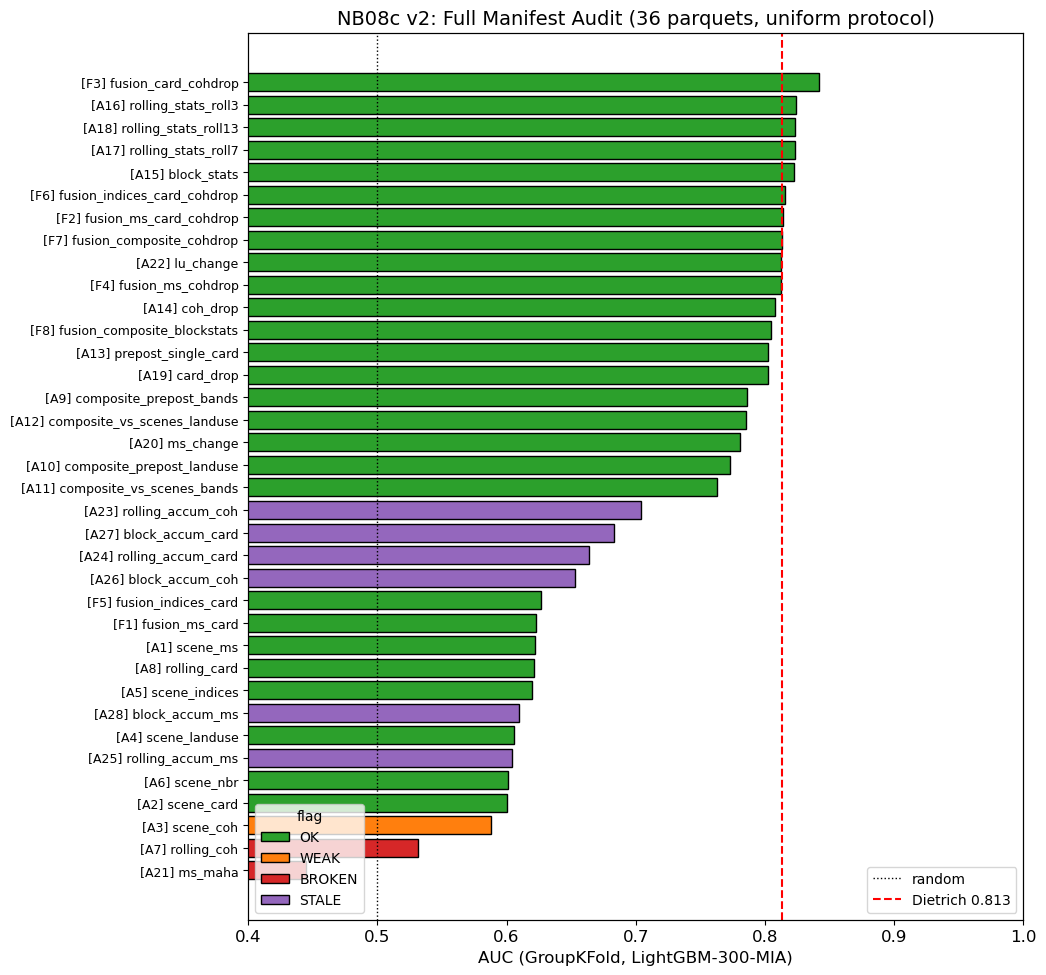

  Plot: cell_c8/parquet_ranking_20260427_015811.png


In [17]:
# @title CELL C8: RANKING + DIAGNOSTIC FLAGS
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL C8: RANKING TABLE + DIAGNOSTIC FLAGS")
print("=" * 70)

if not AUDIT_LOG:
    print("  SKIP: AUDIT_LOG is empty. Run C1..C7 first.")
else:
    rows = []
    for exp_name, res in AUDIT_LOG.items():
        auc = res.get('auc_groupkfold', float('nan'))
        nfeat = res.get('n_features', 0)
        ncity = res.get('n_cities', 0)
        nan_pct = res.get('overall_nan_pct', float('nan'))

        # diagnostic flag
        if nfeat == 0 or (isinstance(nan_pct, float) and nan_pct > 90):
            flag = 'EMPTY'
        elif ncity < 10:
            flag = 'STALE'
        elif auc < 0.55:
            flag = 'BROKEN'
        elif auc < 0.60:
            flag = 'WEAK'
        else:
            flag = 'OK'

        rows.append({
            'parquet_id': res.get('parquet_id', '?'),
            'manifest_key': res.get('manifest_key', ''),
            'format': res.get('format', ''),
            'auc': auc,
            'auc_mean_fold': res.get('auc_mean', float('nan')),
            'auc_std_fold': res.get('auc_std', float('nan')),
            'f1': res.get('f1_groupkfold', float('nan')),
            'precision': res.get('precision', float('nan')),
            'recall': res.get('recall', float('nan')),
            'n_features': nfeat,
            'n_buildings': res.get('n_buildings', 0),
            'n_cities': ncity,
            'n_rows_raw': res.get('n_rows_raw', 0),
            'n_cities_raw': res.get('n_cities_raw', 0),
            'overall_nan_pct': nan_pct,
            'flag': flag,
        })

    rank_df = pd.DataFrame(rows).sort_values('auc', ascending=False).reset_index(drop=True)

    print(f"\n  {'Rank':>4s}  {'ID':<4s} {'Parquet':<35s} {'Format':<10s} "
          f"{'AUC':>6s} {'F1':>6s} {'nFeat':>6s} {'nCity':>5s} {'NaN%':>6s}  {'Flag'}")
    print("  " + "-" * 100)
    for idx, r in rank_df.iterrows():
        nan_s = f"{r['overall_nan_pct']:5.1f}" if pd.notna(r['overall_nan_pct']) else '  nan'
        print(f"  {idx+1:>4d}  {r['parquet_id']:<4s} {r['manifest_key']:<35s} "
              f"{r['format']:<10s} {r['auc']:6.3f} {r['f1']:6.3f} "
              f"{int(r['n_features']):>6d} {int(r['n_cities']):>5d} {nan_s}  {r['flag']}")

    # save master ranking
    save_result(rank_df, 'parquet_ranking', 'cell_c8')

    # diagnostic breakdown
    print(f"\n  Flag counts:")
    for flag, n in rank_df['flag'].value_counts().items():
        print(f"    {flag:<20s} {n}")

    # rebuild candidates
    broken = rank_df[rank_df['flag'] == 'BROKEN']
    empty = rank_df[rank_df['flag'] == 'EMPTY']
    stale = rank_df[rank_df['flag'] == 'STALE']

    print(f"\n  NB03e / NB05a rebuild candidates:")
    if len(broken):
        print(f"    BROKEN (AUC<0.55 despite having features - suspect aggregation / composite window):")
        for _, r in broken.iterrows():
            print(f"      [{r['parquet_id']}] {r['manifest_key']}  AUC={r['auc']:.3f}  NaN={r['overall_nan_pct']:.1f}%")
    if len(empty):
        print(f"    EMPTY (no usable features - NB05a build issue):")
        for _, r in empty.iterrows():
            print(f"      [{r['parquet_id']}] {r['manifest_key']}  nfeat={int(r['n_features'])}  NaN={r['overall_nan_pct']:.1f}%")
    if len(stale):
        print(f"    STALE (fewer than 10 cities - missing per-tier build):")
        for _, r in stale.iterrows():
            print(f"      [{r['parquet_id']}] {r['manifest_key']}  nCity={int(r['n_cities'])}/{int(r['n_cities_raw'])}")

    # ranking bar plot
    fig, ax = plt.subplots(figsize=(10, max(6, len(rank_df) * 0.32)))
    colors = {'OK': '#2ca02c', 'WEAK': '#ff7f0e', 'BROKEN': '#d62728',
              'EMPTY': '#7f7f7f', 'STALE': '#9467bd'}
    bar_labels = [f"[{r['parquet_id']}] {r['manifest_key']}" for _, r in rank_df.iterrows()]
    bar_colors = [colors.get(r['flag'], '#1f77b4') for _, r in rank_df.iterrows()]
    ax.barh(range(len(rank_df)), rank_df['auc'].values, color=bar_colors, edgecolor='black')
    ax.set_yticks(range(len(rank_df)))
    ax.set_yticklabels(bar_labels, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0.5, color='black', linestyle=':', linewidth=1, label='random')
    ax.axvline(0.813, color='red', linestyle='--', linewidth=1.5, label='Dietrich 0.813')
    ax.set_xlabel('AUC (GroupKFold, LightGBM-300-MIA)')
    ax.set_xlim(0.4, 1.0)
    ax.set_title(f'NB08c v2: Full Manifest Audit ({len(rank_df)} parquets, uniform protocol)')
    ax.legend(loc='lower right')
    # legend for flags
    from matplotlib.patches import Patch
    flag_handles = [Patch(facecolor=col, edgecolor='black', label=flg) for flg, col in colors.items()
                    if flg in rank_df['flag'].values]
    ax2 = ax.twinx()
    ax2.set_yticks([])
    ax2.legend(handles=flag_handles, loc='lower left', title='flag')
    save_fig(fig, 'parquet_ranking', 'cell_c8')


# CELL C9: SAVE AUDIT LOG + REGISTRY FLUSH

Persist AUDIT_LOG to JSON for NB13 aggregation.


In [18]:
# @title CELL C9: SAVE AUDIT LOG + REGISTRY
print("=" * 70)
print("CELL C9: SAVE AUDIT LOG + REGISTRY FLUSH")
print("=" * 70)

if AUDIT_LOG:
    audit_summary = {}
    for name, res in AUDIT_LOG.items():
        summary = {k: v for k, v in res.items()
                   if k not in ('y_true', 'y_proba', 'groups', 'fold_aucs')}
        if 'fold_aucs' in res:
            summary['fold_aucs'] = [float(x) for x in res['fold_aucs']]
        audit_summary[name] = summary
    save_result(audit_summary, 'audit_log', 'cell_c9', fmt='json')

# OOF parquets per parquet key (for NB11 stacking + NB12 overlap analysis)
OOF_DIR = OUT_DIR / 'oof_predictions'
OOF_DIR.mkdir(parents=True, exist_ok=True)
oof_count = 0
for name, res in AUDIT_LOG.items():
    if 'y_true' in res and 'y_proba' in res and len(res['y_true']) > 0:
        out = save_oof_from_result(res, model_id=name, oof_dir=OOF_DIR,
                                    variant_id=f'audit_sweep;parquet={res.get("manifest_key", "?")}')
        if out is not None:
            oof_count += 1
print(f"  Saved: {oof_count} OOF prediction parquets -> {OOF_DIR}")

# OOF inventory (for NB12a discovery)
oof_files = sorted(OOF_DIR.glob('oof_*.parquet'))
if oof_files:
    inv_rows = []
    for p in oof_files:
        head = pd.read_parquet(p, columns=['model_id', 'variant_id', 'cm_class'])
        cm = head['cm_class'].value_counts()
        inv_rows.append({
            'file':       p.name,
            'model_id':   head['model_id'].iloc[0],
            'variant_id': head['variant_id'].iloc[0],
            'n_rows':     len(head),
            'TP':         int(cm.get('TP', 0)),
            'FN':         int(cm.get('FN', 0)),
            'FP':         int(cm.get('FP', 0)),
            'TN':         int(cm.get('TN', 0)),
        })
    inv_df = pd.DataFrame(inv_rows)
    save_result(inv_df, 'nb08c_oof_inventory', 'cell_c9')
    print(f"  OOF inventory:\n{inv_df.to_string(index=False)}")

try:
    registry.save()
    print(f"  Registry flushed: {len(AUDIT_LOG)} experiments logged under NB08c_v2")
except Exception as e:
    print(f"  registry.save() error: {e}")

print(f"\n  NB08c complete. Outputs in: {OUT_DIR}")


CELL C9: SAVE AUDIT LOG + REGISTRY FLUSH
  Saved: cell_c9/audit_log_20260427_015812.json (30.6 KB)
    saved oof -> oof_C_A1_scene_ms__20260426_191509_115af1.parquet  TP=5917 FN=1269 FP=241777 TN=231350
    saved oof -> oof_C_A2_scene_card__20260426_191509_115af1.parquet  TP=5881 FN=1451 FP=317173 TN=274090
    saved oof -> oof_C_A3_scene_coh__20260426_191509_115af1.parquet  TP=6110 FN=913 FP=237337 TN=169840
    saved oof -> oof_C_A4_scene_landuse__20260426_191509_115af1.parquet  TP=6109 FN=1077 FP=258266 TN=214861
    saved oof -> oof_C_A5_scene_indices__20260426_191509_115af1.parquet  TP=6063 FN=1123 FP=249159 TN=223968
    saved oof -> oof_C_A6_scene_nbr__20260426_191509_115af1.parquet  TP=5908 FN=1278 FP=249733 TN=223394
    saved oof -> oof_C_A7_rolling_coh__20260426_191509_115af1.parquet  TP=5702 FN=904 FP=152599 TN=90578
    saved oof -> oof_C_A8_rolling_card__20260426_191509_115af1.parquet  TP=6269 FN=1063 FP=333731 TN=257532
    saved oof -> oof_C_A9_composite_prepost_bands__

# CELL C10: DELTA — `was_observed_*` LEAKAGE CONTRIBUTION PER PARQUET

Quantifies the per-parquet AUC contribution of `was_observed_*` modality-availability flags.

Mode A (CLEAN, already run C1-C7): `was_observed_*` excluded. Stored in `AUDIT_LOG`.
Mode B (LEAKY, this cell): `was_observed_*` kept as features. Stored in `AUDIT_LOG_LEAKY`.

Delta = AUC_leaky - AUC_clean. If positive and large, the flag is leaking city identity
via modality-availability. If near zero, the flag carries no city-proxy signal.

Runs the same protocol as C1-C7 (LightGBM-300-MIA, GroupKFold, manifest features, long-aggregated)
but with the LEAKY filter. Outputs a combined ranking table with both AUCs + delta column.


In [19]:
# @title CELL C10: was_observed_* leakage delta (clean vs leaky, same protocol)
print("=" * 70)
print("CELL C10: was_observed_* LEAKAGE DELTA")
print("=" * 70)

AUDIT_LOG_LEAKY = {}

def audit_parquet_leaky(manifest_key, cell_id, pq_id=None):
    '''Same as audit_parquet but uses drop_leakage_leaky (keeps was_observed_* flags).'''
    info = MANIFEST['parquets'].get(manifest_key)
    if info is None:
        return None
    _pq_id = pq_id or info.get('id', '?')
    print(f"\n  --- [{_pq_id}] {manifest_key} (LEAKY mode) ---")

    try:
        df = load_v2(manifest_key)
    except (FileNotFoundError, KeyError) as e:
        print(f"    SKIP load: {e}")
        return None
    if len(df) == 0:
        del df; gc.collect()
        return None

    is_long = 'date' in df.columns

    # --- LEAKY feature selection (keeps was_observed_*) ---
    raw = [c for c in info.get('feature_columns', []) if c in df.columns]
    clean = drop_leakage_leaky(raw)
    clean = [c for c in clean if not _has_count_stat(c)]
    if clean:
        nan_rate = df[clean].isna().mean()
        clean = [c for c in clean if nan_rate.get(c, 1.0) < 1.0]
    feat_cols = clean

    if is_long and feat_cols:
        df = aggregate_long_to_wide(df, feat_cols)
        df = df.merge(df_bldg[['building_id', 'city', TARGET_COL]].drop_duplicates(),
                      on=['building_id', 'city'], how='inner')
        df = df[df[TARGET_COL] >= 0].copy()
        feat_cols = [c for c in df.columns
                     if c not in ('city', 'building_id', TARGET_COL)]
        feat_cols = drop_leakage_leaky(feat_cols)
        feat_cols = [c for c in feat_cols if not _has_count_stat(c)]
        nan_rate = df[feat_cols].isna().mean()
        feat_cols = [c for c in feat_cols if nan_rate[c] < 1.0]

    if len(feat_cols) < 2:
        print(f"    SKIP: {len(feat_cols)} feature columns after cleaning")
        del df; gc.collect()
        return None

    overall_nan = float(df[feat_cols].isna().mean().mean())
    X = df[feat_cols].to_numpy(dtype=np.float32, copy=False)
    y = df[TARGET_COL].values
    groups = df['city'].values
    building_ids = df['building_id'].values

    exp_name = f"C10_leaky_{_pq_id}_{manifest_key}"
    # reuse evaluate_audit but write into AUDIT_LOG_LEAKY instead of AUDIT_LOG
    n_cities = len(np.unique(groups))
    n_folds_actual = min(N_FOLDS, n_cities)
    if n_folds_actual < 2:
        del df, X, y, groups; gc.collect()
        return None
    gkf = GroupKFold(n_splits=n_folds_actual)
    y_proba_oof = np.full(len(y), np.nan)
    fold_id = np.full(len(y), -1, dtype=int)
    fold_aucs = []
    for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups)):
        clf_c = clone(LGBM)
        clf_c.fit(X[tr], y[tr])
        y_proba_oof[te] = clf_c.predict_proba(X[te])[:, 1]
        fold_id[te] = fold_idx
        if len(np.unique(y[te])) > 1:
            fold_aucs.append(roc_auc_score(y[te], y_proba_oof[te]))
    valid = ~np.isnan(y_proba_oof)
    y_v, p_v = y[valid], y_proba_oof[valid]
    pred_v = (p_v >= 0.5).astype(int)
    was_obs_feats = [c for c in feat_cols if 'was_observed_' in c]
    result = {
        'experiment': exp_name,
        'auc_groupkfold': roc_auc_score(y_v, p_v),
        'f1_groupkfold': f1_score(y_v, pred_v),
        'n_features': X.shape[1], 'n_buildings': int(valid.sum()),
        'n_cities': int(len(np.unique(groups))),
        'manifest_key': manifest_key, 'parquet_id': _pq_id,
        'overall_nan_pct': overall_nan * 100,
        'n_was_observed_feats': len(was_obs_feats),
        'y_true': y_v, 'y_proba': p_v, 'groups': groups[valid],
        'building_id': building_ids[valid], 'fold_id': fold_id[valid],
    }
    AUDIT_LOG_LEAKY[exp_name] = result
    print(f"    {exp_name:50s} AUC={result['auc_groupkfold']:.3f}  nfeat={X.shape[1]} (was_observed={len(was_obs_feats)})")

    del df, X, y, groups; gc.collect()
    return result

# run same set as C1-C7 (full manifest minus anything that skipped)
ALL_KEYS = [
    ('A1','scene_ms'), ('A2','scene_card'), ('A3','scene_coh'), ('A4','scene_landuse'),
    ('A5','scene_indices'), ('A6','scene_nbr'),
    ('A7','rolling_coh'), ('A8','rolling_card'),
    ('A9','composite_prepost_bands'), ('A10','composite_prepost_landuse'),
    ('A11','composite_vs_scenes_bands'), ('A12','composite_vs_scenes_landuse'),
    ('A13','prepost_single_card'), ('A14','coh_drop'),
    ('A19','card_drop'), ('A20','ms_change'), ('A21','ms_maha'), ('A22','lu_change'),
    ('A15','block_stats'),
    ('A16','rolling_stats_roll3'), ('A17','rolling_stats_roll7'), ('A18','rolling_stats_roll13'),
    # v7 additions: NB05b v29 R2b/P1d output parquets
    ('A23','rolling_accum_coh'), ('A24','rolling_accum_card'), ('A25','rolling_accum_ms'),
    ('A26','block_accum_coh'), ('A27','block_accum_card'), ('A28','block_accum_ms'),
    ('F1','fusion_ms_card'), ('F2','fusion_ms_card_cohdrop'), ('F3','fusion_card_cohdrop'),
    ('F4','fusion_ms_cohdrop'), ('F5','fusion_indices_card'), ('F6','fusion_indices_card_cohdrop'),
    ('F7','fusion_composite_cohdrop'), ('F8','fusion_composite_blockstats'),
]

for pq_id, mkey in ALL_KEYS:
    audit_parquet_leaky(mkey, cell_id='cell_c10', pq_id=pq_id)

# --- delta table ---
print("\n" + "=" * 70)
print("DELTA TABLE: LEAKY - CLEAN (positive = was_observed_ inflates AUC)")
print("=" * 70)

rows = []
for pq_id, mkey in ALL_KEYS:
    clean_key = f"C_{pq_id}_{mkey}"
    leaky_key = f"C10_leaky_{pq_id}_{mkey}"
    if clean_key not in AUDIT_LOG or leaky_key not in AUDIT_LOG_LEAKY:
        continue
    clean_auc = AUDIT_LOG[clean_key]['auc_groupkfold']
    leaky_auc = AUDIT_LOG_LEAKY[leaky_key]['auc_groupkfold']
    delta = leaky_auc - clean_auc
    n_wo = AUDIT_LOG_LEAKY[leaky_key].get('n_was_observed_feats', 0)
    rows.append({
        'parquet_id': pq_id,
        'manifest_key': mkey,
        'auc_clean': clean_auc,
        'auc_leaky': leaky_auc,
        'delta': delta,
        'n_was_observed': n_wo,
    })

delta_df = pd.DataFrame(rows).sort_values('delta', ascending=False).reset_index(drop=True)

print(f"\n  {'ID':<4s} {'Parquet':<35s} {'AUC_clean':>10s} {'AUC_leaky':>10s} {'delta':>7s} {'nWO':>4s}")
print("  " + "-" * 80)
for _, r in delta_df.iterrows():
    print(f"  {r['parquet_id']:<4s} {r['manifest_key']:<35s} "
          f"{r['auc_clean']:>10.3f} {r['auc_leaky']:>10.3f} "
          f"{r['delta']:>+7.3f} {int(r['n_was_observed']):>4d}")

save_result(delta_df, 'was_observed_delta', 'cell_c10')

# summary
mean_delta = delta_df['delta'].mean()
max_delta = delta_df['delta'].max()
print(f"\n  Mean delta: {mean_delta:+.3f}")
print(f"  Max delta:  {max_delta:+.3f}  (parquet: {delta_df.iloc[0]['manifest_key']})")
print(f"  Parquets with delta > 0.05 (material leakage): "
      f"{int((delta_df['delta'] > 0.05).sum())}")
print(f"  Parquets with delta > 0.10 (severe leakage):   "
      f"{int((delta_df['delta'] > 0.10).sum())}")

# ---- OOF parquets for leaky-mode audits (marked with leakage_demo variant) ----
OOF_DIR_LEAKY = OUT_DIR / 'oof_predictions'
OOF_DIR_LEAKY.mkdir(parents=True, exist_ok=True)
leaky_oof_count = 0
for name, res in AUDIT_LOG_LEAKY.items():
    if 'y_true' in res and 'y_proba' in res and len(res['y_true']) > 0:
        out = save_oof_from_result(res, model_id=name, oof_dir=OOF_DIR_LEAKY,
                                    variant_id=f'leakage_demo_with_leaks;parquet={res.get("manifest_key", "?")}')
        if out is not None:
            leaky_oof_count += 1
print(f"\n  Saved: {leaky_oof_count} LEAKY OOF parquets -> {OOF_DIR_LEAKY}")


CELL C10: was_observed_* LEAKAGE DELTA

  --- [A1] scene_ms (LEAKY mode) ---
    C10_leaky_A1_scene_ms                              AUC=0.622  nfeat=68 (was_observed=0)

  --- [A2] scene_card (LEAKY mode) ---
    C10_leaky_A2_scene_card                            AUC=0.600  nfeat=12 (was_observed=0)

  --- [A3] scene_coh (LEAKY mode) ---
    C10_leaky_A3_scene_coh                             AUC=0.588  nfeat=21 (was_observed=0)

  --- [A4] scene_landuse (LEAKY mode) ---
    C10_leaky_A4_scene_landuse                         AUC=0.606  nfeat=2 (was_observed=0)

  --- [A5] scene_indices (LEAKY mode) ---
    C10_leaky_A5_scene_indices                         AUC=0.620  nfeat=54 (was_observed=0)

  --- [A6] scene_nbr (LEAKY mode) ---
    C10_leaky_A6_scene_nbr                             AUC=0.601  nfeat=6 (was_observed=0)

  --- [A7] rolling_coh (LEAKY mode) ---
    C10_leaky_A7_rolling_coh                           AUC=0.532  nfeat=27 (was_observed=0)

  --- [A8] rolling_card (LEAKY mode

In [20]:
import pandas as pd
from pathlib import Path
V2_DIR = Path(STACK_DIR) / 'dataset' / 'v2'  # same derivation as NB05b cell 4
df_f1 = pd.read_parquet(V2_DIR / 'bda_fusion_ms_card_t1.parquet')
flag_cols = [c for c in df_f1.columns if c.startswith('was_observed_')]
print(f"Flag columns: {flag_cols}")
for fc in flag_cols:
    per_city = df_f1.groupby('city')[fc].agg(['mean','std','count']).round(3)
    print(f"\n{fc}:")
    print(per_city.to_string())

Flag columns: ['was_observed_scene_ms', 'was_observed_scene_card']

was_observed_scene_ms:
              mean    std    count
city                              
Bucha        0.403  0.490   295239
Chernihiv    0.283  0.451  1113894
Dmytrivka    0.361  0.480   232050
Hostomel     0.274  0.446   336566
Irpin        0.296  0.457   282976
Makariv      0.304  0.460   131614
Moschun      0.274  0.446   349605
Okhtyrka     0.323  0.468   662472
Trostianets  0.243  0.429   373120
Volnovakha   0.365  0.481   277760

was_observed_scene_card:
              mean    std    count
city                              
Bucha        0.363  0.481   295239
Chernihiv    0.315  0.464  1113894
Dmytrivka    0.364  0.481   232050
Hostomel     0.391  0.488   336566
Irpin        0.423  0.494   282976
Makariv      0.343  0.475   131614
Moschun      0.392  0.488   349605
Okhtyrka     0.231  0.421   662472
Trostianets  0.201  0.401   373120
Volnovakha   0.243  0.429   277760
